In [ ]:
import numpy as np

signal_list = [1, 3, 5, 2, 9]
signal_array = np.array(signal_list)
print(signal_array)

zeros_arr = np.zeros(10)
print(zeros_arr)
ones_arr = np.ones(5)
print(ones_arr)

range_arr = np.arange(0, 10, 2) # Аналог range()
print(range_arr)
linspace_arr = np.linspace(0, 1, 5) # 5 точек от 0 до 1, равномерно распределенных
print(linspace_arr)


In [ ]:
arr = np.array([[1, 2, 3], [4, 5, 6]])

print(arr.ndim)   # Количество измерений
print(arr.shape)  # Размерность
print(arr.size)   # Общее количество элементов
print(arr.dtype)  # Тип данных (м. быть int64, int32, float32, complex64 и т.д.)

In [ ]:
arr = np.array([10, 20, 30, 40, 50])

print(arr[0])
print(arr[-1])

# Срезы [start:stop:step]
print(arr[1:4])
print(arr[::2])

# Для двумерных массивов
arr_2d = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
print(arr_2d[1, 2])   # строка 1, столбец 2
print(arr_2d[0, :])   # вся первая строка
print(arr_2d[:, 1])   # весь второй столбец

 Срезы возвращают представление, а не копию. Изменения в представлении влияют на исходный массив! Чтобы создать копию, используйте .copy()

In [ ]:
arr = np.array([10, 20, 30, 40, 50])

view = arr[1:4]
view[0] = 999
print(arr)  # Исходный массив изменился

copy = arr[1:4].copy()
copy[0] = 0
print(arr)  # массив не изменился

print(copy)

In [ ]:
a = np.array([1, 2, 3, 4])
b = np.array([5, 6, 7, 8])

# Поэлементные арифметические операции
print(a + b)
print(a * b)
print(a ** 2)
print(np.sin(a))

# Операции со скаляром
print(a * 10)
print(a > 2)

In [ ]:
t = np.linspace(0, 1, 100) # 1 секунда сигнала

frequency = 5
sine_wave = np.sin(2 * np.pi * frequency * t)

print(np.sum(sine_wave))     # Сумма всех элементов (около 0 для синуса)
print(np.mean(sine_wave))    # Среднее значение (тоже около 0)
print(np.std(sine_wave))     # Стандартное отклонение
print(np.max(sine_wave), np.min(sine_wave)) # Пиковые значения

In [ ]:
# Скалярное произведение
a = np.array([1, 2])
b = np.array([3, 4])
dot_product = np.dot(a, b)
print(dot_product)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Параметры сигнала
fs = 1000          # ЧД (Гц)
T = 1              # Длительность (с)
f = 5              # Частота (Гц)

t = np.linspace(0, T, int(fs * T), endpoint=False)
signal = np.sin(2 * np.pi * f * t)

plt.figure(figsize=(10, 4))
plt.plot(t, signal)
plt.title('Гармонический сигнал')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.grid(True)
plt.xlim(0, 1)
plt.show()

Задание 1.

Сгенерируйте сигнал состоящий из суммы двух синусоид с разными частотами и отличающимися амплитудами.

Ограничьте сигнал по амплитуде: создайте новый массив, где все значения сигнала выше 0.5 будут равны 0.5, а ниже -0.5 будут равны -0.5. (Используйте np.clip())

Найдите пиковое значение и среднюю мощность (среднее квадратов) вашего результирующего сигнала.

Задание 2.

Написать программу, которая по названию ноты будет возвращать сигнал длительностью 1 секунда, соответствующий этой ноте по частоте.
<br/>
(Вы должны сгенерировать синусоиду нужной частоты и записать в массив signal)
<br/>
О нотах и научной нотации - в текстовом файлике

100
[ 0.00000000e+00  4.05969138e-05  1.62321562e-04 ...  1.62321562e-04
  4.05969138e-05 -4.81135983e-30]


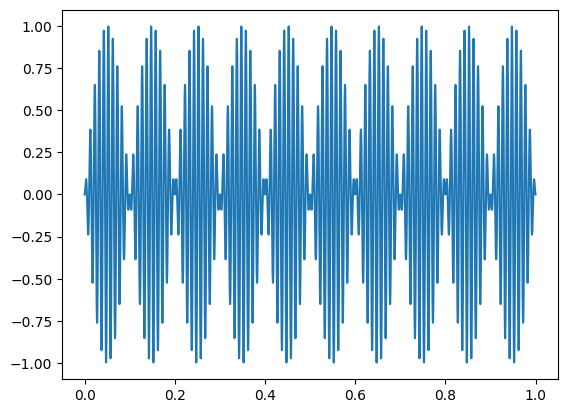

In [34]:
import numpy as np
import matplotlib.pyplot as plt
def get_note_signal(note):
    notes = ["C", "C#", "D", "D#", "E", "E#", "A", "A#", "B", "B#"]
    if '#' in note:
      notename = notes.index(note[0:1])+1
    else:
      notename = notes.index(note[0])+1
    octave = int(note[-1])
    N = 440
    n = 10
    m = 4
    f = N*2**((notename-n)/12 + octave - m)
    fs = 22050        # ЧД (Гц)
    T = 1             # Длительность (с)
    t = np.linspace(0, T, int(fs * T)) #  endpoint=False ?
    signal =  np.sin(2 * np.pi * f * t )
    AM = np.sin(2 * np.pi * 50 * t )
    signal = signal*AM
    plt.plot(t, signal)
    print(f)
    return signal

print(get_note_signal('E6'))

100


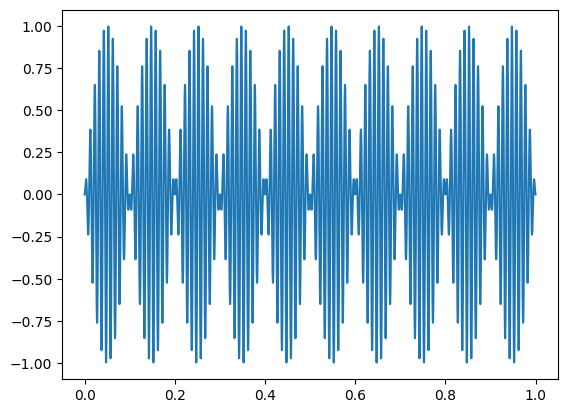

In [35]:
from IPython.display import Audio
signal = get_note_signal("A4")
Audio(signal, rate=22050)

Задание 3.

Написать программу, которая по списку нот будет возвращать мелодию.
1. Модифицируйте функцию get_note_signal, чтобы она принимала не только название ноты, но и ее длительность, и возвращала ноту нужной длины
2. Напишите функцию, которая будет парсить нотную строку. Ноты в строке записываются через пробел, длительности нот - через вертикальную черту после названия ноты (например, G3|4). Значком "-" будет обозначаться дополнительная пауза (с ее длительностью можете поэкспериментировать)
3. Соберите из нот мелодию, добавив после каждой ноты паузу длительностью равной длительности самой ноты
4. Поэксперементируйте с длительностью целой ноты, чтобы получить хороший темп

In [ ]:
# ваш код
def get_melody(notes, T):
    # T - длительность целой ноты
    return

In [ ]:
# мелодии для проверки:
melody_1 = "G3|4 G3|4 G3|4 D#3|8 A#3|16 G3|4 D#3|8 A#3|16 G3|2 - D4|4 D4|4 D4|4 F#4|8 A#3|16 F#3|4 D#3|8 A#3|16 G3|2 - G4|4 G3|8 G4|16 F#4|8 F4|16 E4|16 D#4|16 E4|8 - G#3|8 C#4|4 G#3|8 C4|16 B3|16 A#3|16 A3|8 A#3|4 - D#3|4 F#3|4 D#3|8 A#3|16 G3|4 D#3|8 A#3|16 G3|2"
melody_2 = "D4|8 - G4|8 B4|16 A4|8 G4|4 D5|8 - C5|4 A4|4 - G4|8 B4|16 A4|8 F4|4 G#4|8 D4|2 - D4|8 G4|8 B4|16 A4|8 G4|4 D5|8 F5|4 D#5|8 D#5|4 - A#4|8 E5|8 D5|16 C#5|8 C#4|4 B4|8 G4|2"

In [ ]:
melody_1_signal = get_melody(melody_1, T)
Audio(melody_1_signal, rate=22050)

In [ ]:
melody_2_signal = get_melody(melody_2, T)
Audio(melody_2_signal, rate=22050)